# CP interpretability demo
A tested design is one filled entry in a tensor. Each design variable is a mode, and the entry value is the measured property. A CP decomposition explains those entries with a few components. Plotting one mode shows how a component changes as that variable changes. That plot is the interpretation in Section 3.1.
This file is a finished crossed-barrel run: toughness, with twist (`theta`) and radius (`r`) drawn at the bottom. Those are the two variables that section reads for this dataset. The first code cell lists every CSV in `data/` next to this notebook. `data_file_i` is the index of the file to load, and it is set to the crossed-barrel table.

In [1]:
%matplotlib inline
from pathlib import Path
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_random_state
def find_demo_dir() -> Path:
    # data/ sits next to this notebook. Walk upward so this works from the
    # repository root or from the demo folder itself.
    start = Path.cwd().resolve()
    def is_demo(folder: Path) -> bool:
        return folder.is_dir() and (folder / "demo.ipynb").is_file() and (folder / "data").is_dir()
    for candidate in [start, *start.parents]:
        if is_demo(candidate):
            return candidate
        if not candidate.is_dir():
            continue
        for child in candidate.iterdir():
            if is_demo(child):
                return child
            if not child.is_dir():
                continue
            for grandchild in child.iterdir():
                if is_demo(grandchild):
                    return grandchild
    raise FileNotFoundError("Could not find the demo folder (demo.ipynb next to data/).")
demo_dir = find_demo_dir()
csv_files = sorted((demo_dir / "data").glob("*.csv"))
if not csv_files: raise FileNotFoundError(demo_dir / "data")

## Data
Load a `.csv` file from `demo/data/` folder

In [2]:
print("Data files:\n")
for index, csv_file in enumerate(csv_files): print(f"({index}) {csv_file.name}")

Data files:

(0) Cogni-e-SpinDB 1.0.csv
(1) crossed_barrel_cleaned.csv


In [3]:
data_file_i = 1  # crossed_barrel_cleaned.csv

## Configuration

In [4]:
# Crossed barrel: one row is one 3D-printed design and its measured toughness.
# n is the number of struts, theta is the twist in degrees, r is the radius, t is the wall thickness.
feature_columns = ["n", "theta", "r", "t"]
target_column = "toughness_mean"
modes_to_plot = ["theta", "r"]  # the two modes Section 3.1 reads for this dataset
log_target = True   # toughness spans a wide range; take a log before scaling it to [0, 1]
rank = 4            # number of CP components. Section 3.1 uses 4 for crossed barrel
epochs = 3000
learning_rate = 1e-3
weight_decay = 1e-4
train_size = 0.8    # fit on 80% of the tested designs; the rest is only for the R² line
random_state = 28077935
# random_state = int( random.random() * 1e8 )
# print(f"random_state = {random_state}")

## Table
The example table is the cleaned crossed-barrel file selected by `data_file_i`. The rest of the notebook only sees the dataframe `df`: the design columns named above, plus the target. Rows with a missing value in those columns are dropped.
If the selected file is the Cogni-e-Spin CSV, the notebook applies that file's row cuts from `interpret.ipynb` (three polymers, and bounds on flow rate, distance, and voltage). Any other file skips that block.

In [5]:
path = csv_files[data_file_i]
if not path.is_file():
    raise FileNotFoundError(path)
df = pd.read_csv(path)
# Same cuts as interpret.ipynb. This block does not run for the crossed-barrel file.
if path.name == "Cogni-e-SpinDB 1.0.csv":
    df = df[df["polymer(s)"].isin(["PVDF", "PVA", "PAN"])].copy()
    df = df[
        (df["flow_rate_ml/h"] < 5)
        & (df["tip_collector_distance_cm"] < 45)
        & (df["voltage_kv"] < 40)
    ]
missing = [column for column in feature_columns + [target_column] if column not in df.columns]
if missing:
    raise KeyError(f"Columns not in the table: {missing}")
if len(modes_to_plot) != 2 or any(mode not in feature_columns for mode in modes_to_plot):
    raise ValueError("modes_to_plot must be two names from feature_columns.")
# Keep only the columns that define the tensor, and drop an incomplete design.
df = df[feature_columns + [target_column]].dropna().copy()
print(f"{path.name}: {len(df)} rows, columns {feature_columns + [target_column]}")
df.head()

crossed_barrel_cleaned.csv: 600 rows, columns ['n', 'theta', 'r', 't', 'toughness_mean']


,n,theta,r,t,toughness_mean
0,6,0,1.5,0.70,1.135453
1,6,0,1.5,1.05,1.406492
2,6,0,1.5,1.40,1.343498
3,6,0,1.7,0.70,3.102525
4,6,0,1.7,1.05,3.196597


## Tensor
A mode is one design variable. An entry exists only when that combination was actually tested. Duplicate tests of the same design are averaged into one entry. Designs that were never built stay missing; they are not stored as zeros.
Each distinct value is then mapped to a contiguous index, 0, 1, 2, .... Numeric values are sorted, so the later plots run from low to high. Other values keep first-seen order. The original values are saved and reused as the tick labels. After the optional log, the property is scaled to [0, 1].

In [6]:
def level_order(series):
    # Sort a numeric mode so the axis reads left to right. Keep other modes
    # in the order they first appear (polymer names, for example).
    if pd.api.types.is_numeric_dtype(series):
        return sorted(series.unique().tolist())
    return list(dict.fromkeys(series.tolist()))
def dataframe_to_tensor(frame, features, target, take_log):
    # One row per design. Repeated tests of the same design become their mean.
    design = frame.groupby(features, as_index=False)[target].mean()
    observed = design[target].to_numpy(dtype=float)
    if take_log:
        if np.any(observed <= 0):
            raise ValueError("log_target=True requires a strictly positive target.")
        observed = np.log(observed)
    span = observed.max() - observed.min()
    if span == 0:
        raise ValueError("The target is constant, so it cannot be scaled.")
    observed = (observed - observed.min()) / span
    # labels remembers the real design value behind each index.
    labels = {}
    coded = []
    for column in features:
        levels = level_order(design[column])
        mapping = {level: index for index, level in enumerate(levels)}
        labels[column] = levels
        coded.append(design[column].map(mapping).to_numpy())
    # A sparse tensor holds the tested designs only. Its shape is the number
    # of distinct values along each mode, not the number of rows.
    indices = torch.tensor(np.column_stack(coded), dtype=torch.long)
    values = torch.tensor(observed, dtype=torch.float32)
    shape = torch.Size([int(indices[:, axis].max()) + 1 for axis in range(indices.shape[1])])
    sparse = torch.sparse_coo_tensor(indices.t(), values, size=shape).coalesce()
    return sparse, labels
sparse_tensor, level_labels = dataframe_to_tensor(df, feature_columns, target_column, log_target)
print(
    f"Tensor shape {list(sparse_tensor.shape)}, "
    f"{int(sparse_tensor.values().numel())} observed entries."
)

Tensor shape [4, 9, 11, 3], 600 observed entries.


## CP decomposition
The model is the same reconstruction as `tensor_completion_models/CPD.py`, and the class in the next cell is that model. For a design whose value on mode \(k\) has index \(i_k\),
\[
\hat{y} = \sum_{r=1}^{R} \prod_{k=1}^{d} A^{(k)}_{i_k, r}.
\]
\(R\) is `rank`. \(A^{(k)}\) is the factor matrix for design variable \(k\): one row per value of that variable, one column per component. The product across modes is why a single component can be read off one variable at a time. The factor plots after the test-set figure are those columns.
Factor rows start as uniform random values on [0, 1]. Adam then minimizes mean absolute error on 80% of the observed entries. A design that was never tested is not filled with zero, and it is not part of the loss.

In [7]:
class CPD(nn.Module):
    def __init__(self, sizes, rank, seed):
        super(CPD, self).__init__()
        self.rank = rank
        self.sizes = sizes
        self.nmode = len(self.sizes)
        self.random_state = seed
        # One embedding per mode. Row i of mode k is the factor vector for the
        # i-th value of that design variable. Its length is `rank`.
        self.embeds = nn.ModuleList([nn.Embedding(self.sizes[i], self.rank)
                                     for i in range(len(self.sizes))])
        self._initialize()
    def _initialize(self):
        # Same start as the paper code: every factor entry is drawn from [0, 1].
        rng = check_random_state(self.random_state)
        for m in range(self.nmode):
            self.embeds[m].weight.data = torch.tensor(rng.random_sample((self.sizes[m], self.rank)))
    def recon(self, idxs):
        # idxs is one tested design per row. Look up the factor row for each
        # mode, multiply across modes, then sum across components.
        facs = [self.embeds[m](idxs[:, m]).unsqueeze(-1) for m in range(self.nmode)]
        concat = torch.concat(facs, dim=-1)
        rec = torch.prod(concat, dim=-1)
        return rec.sum(-1)
    def forward(self, idxs):
        return self.recon(idxs)
# Coordinates of the entries that were actually tested. Missing designs are absent.
entries = sparse_tensor.indices().t()
observed = sparse_tensor.values()
X_train, X_test, Y_train, Y_test = train_test_split(
    entries,
    observed,
    train_size=train_size,
    shuffle=True,
    random_state=random_state,
)
model = CPD(sparse_tensor.shape, rank, random_state)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
# Fixed number of passes over the training entries. The experiment notebooks
# add early stopping; this demo does not, so the loop always runs `epochs` steps.
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    loss = (model(X_train) - Y_train).abs().mean()
    loss.backward()
    optimizer.step()
    if epoch == 1 or epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | MAE {loss.item():.4f}")
model.eval()
with torch.no_grad():
    predictions = model(X_test)
heldout_r2 = r2_score(Y_test.numpy(), predictions.numpy())
print(f"Held-out R² = {heldout_r2:.3f}")

Epoch    1 | MAE 0.4695
Epoch  500 | MAE 0.1045
Epoch 1000 | MAE 0.0875
Epoch 1500 | MAE 0.0761
Epoch 2000 | MAE 0.0704
Epoch 2500 | MAE 0.0689
Epoch 3000 | MAE 0.0679
Held-out R² = 0.608


## Test set
The fit uses 80% of the observed designs. This plot is the other 20%. Both axes are the scaled property. The box reports R² and mean absolute error on that holdout.

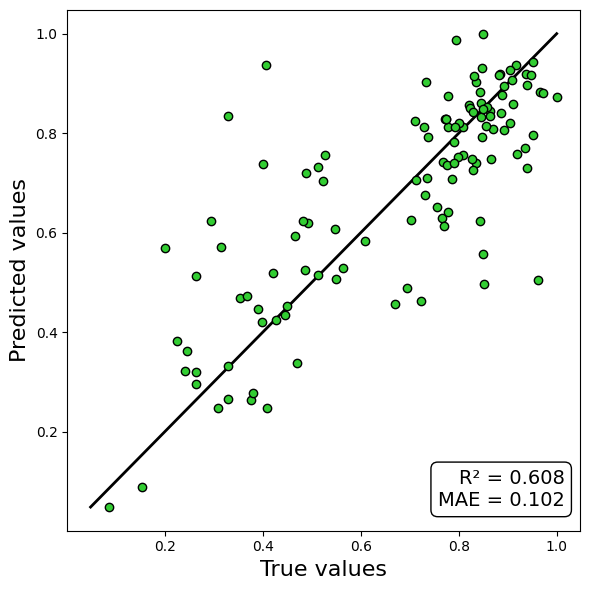

In [8]:
y_true = Y_test.detach().cpu().numpy()
y_hat = predictions.detach().cpu().numpy()
test_r2 = r2_score(y_true, y_hat)
test_mae = float(np.mean(np.abs(y_true - y_hat)))
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_true, y_hat, color="limegreen", edgecolors="black")
low = min(y_true.min(), y_hat.min())
high = max(y_true.max(), y_hat.max())
ax.plot([low, high], [low, high], color="black", lw=2, zorder=0)
ax.set_xlabel("True values", fontsize=16)
ax.set_ylabel("Predicted values", fontsize=16)
ax.text(
    0.97, 0.04,
    f"R² = {test_r2:.3f}\nMAE = {test_mae:.3f}",
    transform=ax.transAxes,
    fontsize=14,
    ha="right",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="black"),
)
plt.tight_layout()
plt.show()

## Factor plots
A CP model can rescale one mode's column and compensate in another mode, so the raw factor entries are not on a shared axis. Dividing each component by its L2 norm, as in `interpret.ipynb`, puts the bars on a common scale. The horizontal axis is the original design value, not the integer index stored in the tensor.
One group of bars is one value of the variable. Bar color is the component. A taller bar means that component puts more weight on that setting.

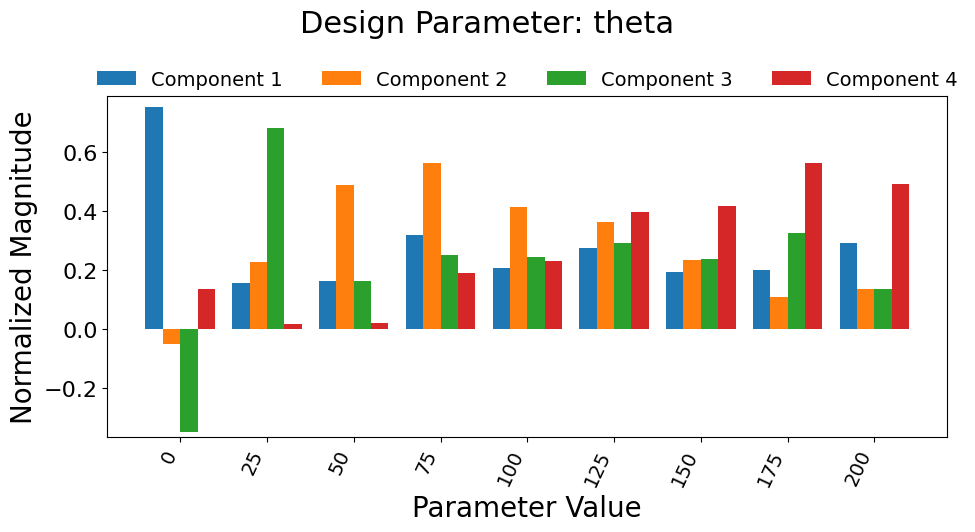

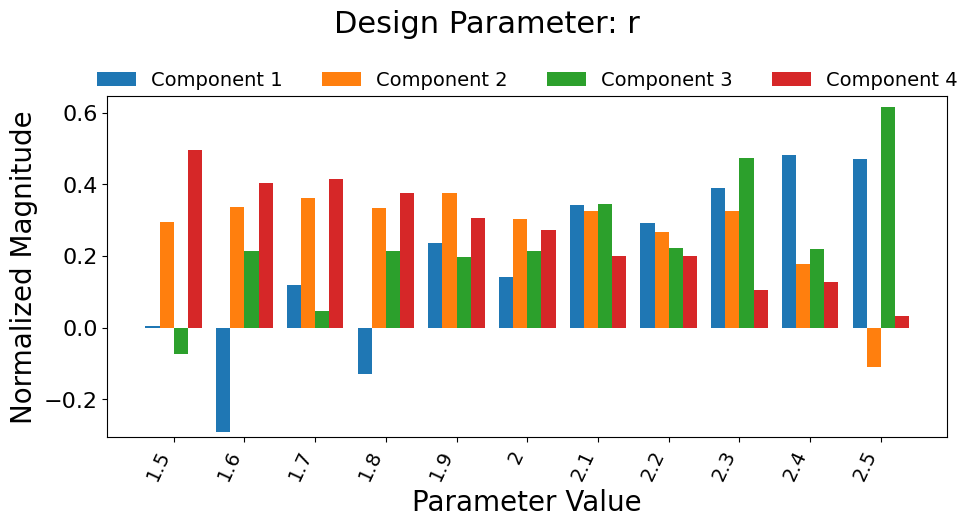

In [9]:
def normalize_factors(fitted):
    # Divide each column by its length. A column of all zeros is left alone.
    scaled = []
    for embedding in fitted.embeds:
        weight = embedding.weight.detach().cpu().numpy()
        norm = np.linalg.norm(weight, ord=2, axis=0)
        norm[norm == 0] = 1.0
        scaled.append(weight / norm)
    return scaled
def format_level(value):
    # Print 75 instead of 75.0, and leave strings such as a polymer name unchanged.
    if isinstance(value, (float, np.floating)):
        if np.isfinite(value) and abs(float(value) - round(float(value))) < 1e-8:
            return str(int(round(float(value))))
        return f"{float(value):g}"
    return str(value)
def plot_factor_components(factor, labels, mode_name, n_components):
    arr = np.asarray(factor)
    n_groups, n_bars = arr.shape
    x = np.arange(n_groups)
    width = 1 / (n_components + 1)
    fig = plt.figure(figsize=(10, 6.2))
    ax = fig.add_axes([0.12, 0.28, 0.84, 0.55])
    for component in range(n_bars):
        ax.bar(
            x + component * width,
            arr[:, component],
            width=width,
            label=f"Component {component + 1}",
        )
    ax.set_xticks(x + width * (n_bars - 1) / 2)
    ax.set_xticklabels([format_level(level) for level in labels], fontsize=14, rotation=65, ha="right")
    ax.tick_params(axis="y", labelsize=16)
    ax.set_xlabel("Parameter Value", fontsize=20)
    ax.set_ylabel("Normalized Magnitude", fontsize=20)
    fig.text(0.5, 0.97, f"Design Parameter: {mode_name}", ha="center", va="top", fontsize=22)
    fig.legend(
        *ax.get_legend_handles_labels(),
        loc="upper center",
        bbox_to_anchor=(0.54, 0.90),
        ncol=min(n_components, 4),
        frameon=False,
        fontsize=14,
    )
    highest = float(np.nanmax(arr))
    lowest = float(np.nanmin(arr))
    ax.set_ylim(0.0 if lowest >= -1e-6 else lowest * 1.05, max(0.5, highest * 1.05))
    plt.show()
factors = normalize_factors(model)
for mode_name in modes_to_plot:
    mode_index = feature_columns.index(mode_name)
    plot_factor_components(factors[mode_index], level_labels[mode_name], mode_name, rank)

Please note this demo was created with heavy usage of cursor.ai, apologies for any mistakes.